In [13]:
###########################################################################
# Function definitions
###########################################################################
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import cartesian_to_spherical
import os

###############################################################################
# function to calculate grid volume
###############################################################################

def compute_grid_cell_volumes(X, Y, Z):
    """
    Computes the volume of each cell in a structured 3D grid given by X, Y, Z arrays.
    These should be generated by np.meshgrid(..., indexing='ij') and represent grid point centers.
    
    Returns:
        volumes: 3D array of shape (nx, ny, nz) with the volume of each grid cell.
    """
    def compute_edges(coords):
        edges = np.empty(len(coords) + 1)
        edges[1:-1] = (coords[1:] + coords[:-1]) / 2
        edges[0] = coords[0] - (coords[1] - coords[0]) / 2
        edges[-1] = coords[-1] + (coords[-1] - coords[-2]) / 2
        return edges

    # Extract 1D coordinate arrays assuming regular structured grid
    x_coords = X[:,0,0]
    y_coords = Y[0,:,0]
    z_coords = Z[0,0,:]

    # Compute edges along each axis
    x_edges = compute_edges(x_coords)
    y_edges = compute_edges(y_coords)
    z_edges = compute_edges(z_coords)

    # Compute cell widths
    dx = np.diff(X,axis=0)
    dy = np.diff(Y,axis=1)
    dz = np.diff(Z,axis=2)

    # Pad the differenced arrays to match the original dimensions
    dx_padded = np.concatenate([dx[[0], :, :], dx], axis=0)
    dy_padded = np.concatenate([dy[:, [0], :], dy], axis=1)
    dz_padded = np.concatenate([dz[:, :, [0]], dz], axis=2)
    
    volumes = dx_padded * dy_padded * dz_padded
    return volumes 

###############################################################################
# Function to calculate dust grain size distribution
###############################################################################

def get_size_distribution(nsizes, amin, amax, slope):
    """create grain size distribution to be used in Mocassin.

    Parameters:
    - nsizes (int or float): The number of size intervals to generate (will be rounded).
    - amin (float): The minimum size value (must be > 0).
    - amax (float): The maximum size value (must be >= amin).
    - slope (float): The exponent to apply to the size in the power-law distribution.

    Returns:
    - str: A formatted string showing each size and its corresponding power-law value.
           Includes a header with the number of sizes and a footer with the slope used.
           Each line in the main body contains:
             index, size (log-spaced), and size^slope in scientific notation.
       """
    sizes = np.logspace(np.log10(amin), np.log10(amax), nsizes)
    weights = sizes ** slope

    output = f"{nsizes} sizes\n\n"
    
    for i in range(nsizes):
        print(sizes[i],'%e'%(weights[i]))
        output += f"{i}\t{sizes[i]:.6f}\t{weights[i]:.6e}\n"

    output += f"\n slope (p): {slope}"
    
    return sizes, weights, output

###############################################################################
# function to write dustspecies file for Mocassin
###############################################################################
def export_dust_input_file(dust_species_info, output_file_path):
    """
    Exports a list of dust species dictionaries to a formatted input file
    for Mocassin.

    Args:
        dust_species_info (list of dict): A list where each dictionary describes a dust species:
                                         [{'path': 'species_path', 'abundance': float,
                                           'min_radius_micron': float, 'max_radius_micron': float}, ...]
        output_file_path (str): The full path including filename where the input file should be written.
    """
    try:
        with open(output_file_path, 'w') as f:
            # Write the total number of dust species on the first line
            f.write(f"{len(dust_species_info)}\n")

            # Write details for each dust species
            for species_data in dust_species_info:
                species_path = species_data['path']
                abundance = species_data['abundance']
                min_radius = species_data['min_radius_micron']
                max_radius = species_data['max_radius_micron']

                # Format the line as required by your Fortran code
                # Using f-strings with alignment for clean output, similar to your example
                # 'dustData/sil-dlee.nk' 0.95  0.1 5.1
                line = f"'{species_path}' {abundance: <.4f} {min_radius: <.4g} {max_radius: <.4g}\n"
                f.write(line)
        print(f"Successfully exported dust input file to: {output_file_path}")

    except IOError as e:
        print(f"Error writing file {output_file_path}: {e}")
    except KeyError as e:
        print(f"Missing expected key in dust_species_info dictionary: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

###############################################################################
# function to calculate Ndust based on adopted grain properties
###############################################################################

def calculate_ndust(total_dust_mass, dust_species_info, dust_species_densities, grain_sizes, grains_weights, grid_cell_volume):
    """
    Calculates the Ndust value required to achieve a total_target_dust_mass,
    with dust species properties provided directly as an argument.

    Args:
        total_dust_mass (float): The desired total dust mass in the grid cell, IN SOLAR MASSES.
        dust_species_info (list of dict): A list where each dictionary describes a dust species:
                                         [{'path': 'species_path', 'abundance': float,
                                           'min_radius_micron': float, 'max_radius_micron': float}, ...]
        grain_sizes (float): array of grain sizes in microns to use.
        grain_weights (float): array of grain weights to use.
        grid_cell_volume (float): The volume of the grid cell (dV) in cm^3.
        dust_species_densities (dict): A dictionary where keys are dust species file paths
                                      (e.g., 'dustData/sil-dlee.nk') and values are
                                      their material densities (rho) in g/cm^3.
        power_law_index (float): The power-law index for the grain size distribution
                                 n(a) ~ a^(-p). Default is 3.5 (MRN distribution).

    Returns:
        float: The calculated Ndust value.
    """
    # Solar Mass to gram conversion factor
    SOLAR_MASS_TO_GRAMS = 1.989e33 # 1 Solar Mass = 1.989 x 10^33 grams

    # --- Convert target dust mass from Solar Masses to grams ---
    total_target_dust_mass_grams = total_dust_mass * SOLAR_MASS_TO_GRAMS

    # --- Use Provided Dust Species Info ---
    dust_species_data = dust_species_info

    grain_radii_cm = grain_sizes * 1e-4 # convert from microns to cm

    # --- Calculate Total Mass per unit Ndust (assuming Ndust = 1) ---
    total_mass_per_unit_Ndust_per_dV = 0.0

    for ai in range(grain_sizes.size):
        current_grain_radius_cm = grain_radii_cm[ai]
        current_grain_weight = grain_weights[ai]

        for species_data in dust_species_data:
            species_path = species_data['path']
            abundance = species_data['abundance']
            min_radius_micron = species_data['min_radius_micron']
            max_radius_micron = species_data['max_radius_micron']

            if min_radius_micron <= grain_sizes[ai] <= max_radius_micron:
                
                rho_species = dust_species_densities[species_path]

                grain_volume_cm3 = (4/3) * np.pi * (current_grain_radius_cm ** 3)

                total_mass_per_unit_Ndust_per_dV += (grain_volume_cm3 *
                                                    rho_species *
                                                    current_grain_weight *
                                                    abundance)

    # Use the converted mass in grams for the final calculation
    ndust = total_target_dust_mass_grams / (total_mass_per_unit_Ndust_per_dV * grid_cell_volume)

    return ndust


Final grid size used (xy,z):  21 21
[0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
80000.0
0.0001 1.000000e+14
0.0001374690717473591 3.283088e+13
0.00018897745687080546 1.077867e+13
0.00025978555577206217 3.538731e+12
0.00035712479205357134 1.161796e+12
0.000490936136615731 3.814279e+11
0.0006748853498779922 1.252261e+11
0.0009277586258361925 4.111284e+10
0.001275381170993067 1.349771e+10
0.0017532546570047664 4.431416e+09
0.002410182902351797 1.454873e+09
0.0033132560632765738 4.776475e+08
0.004554702354799399 1.568159e+08
0.006261307047997834 5.148403e+07
0.008607360678134595 1.690266e+07
0.01183245882617881 5.549291e+06
0.016265971313236472 1.821881e+06
0.022360679774997897 5.981395e+05
0.030739018923089043 1.963745e+05
0.04225664397781557 6.447146e+04
0.05808981622788932 2.116655e+04
0.07985553114822622 6.949163e+03
0.10977665740838981 2.281471e+03
0.15090895193459183 7.490270e+02
0.2074531354081517 2.459122e+02
0.2851838

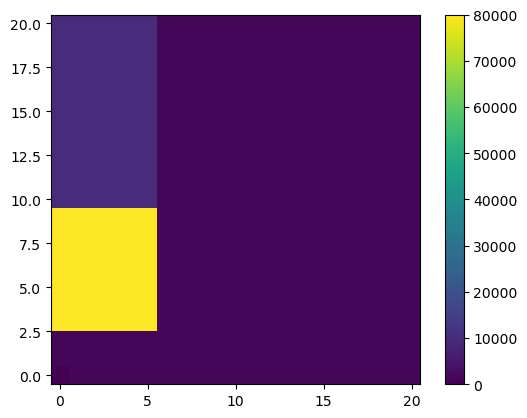

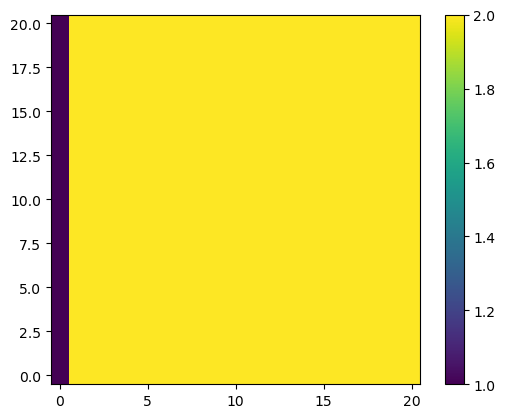

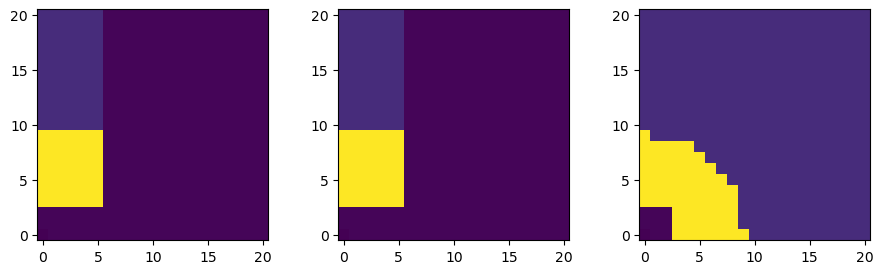

In [21]:
# generate test problem more similar to NGC6302


#########################################################################
# define 3D grid
#########################################################################

symmetricXYZ = True

xy_span = 1
z_span = 1
grid_z_sz = 21
grid_xy_sz = int(xy_span/z_span*grid_z_sz)
if (grid_xy_sz%2 == 0):
    grid_xy_sz = grid_xy_sz+1
    
print('Final grid size used (xy,z): ', grid_xy_sz,grid_z_sz)

# using uniform spacing
if symmetricXYZ:
    span_xy = np.linspace(0,xy_span, grid_xy_sz)
    span_z = np.linspace(0,z_span, grid_z_sz)
else:
    span_xy = np.linspace(-xy_span, xy_span, grid_xy_sz)
    span_z = np.linspace(-z_span, z_span, grid_z_sz)
    

X,Y,Z = np.meshgrid(span_xy, span_xy, span_z, indexing='ij')
volumes = compute_grid_cell_volumes(X, Y, Z)

# X,Y,Z = np.meshgrid(span_xy, span_xy, span_z, indexing='xy') # if using lg2D in Mocassin
# volumes = compute_grid_cell_volumes_XY(X, Y, Z)

R, Lat, Lon = cartesian_to_spherical(X,Y,Z)
print(span_z)
Max_dens = 80000
Rout = 8.e17  # span of the lobes

#########################################################################
## make uniform density sphere

radius = np.sqrt(X**2+Y**2+Z**2)
radius_xy = np.sqrt(X**2+Y**2)

gas_dens = X*0+1 
gas_dens[radius>X.max()] = 0
gas_dens[radius_xy<X.max()*0.15] = 1000/Max_dens
gas_dens[radius_xy>X.max()*0.45] = 10000/Max_dens
gas_dens[np.abs(Z)>Z.max()*0.25] = 1000/Max_dens


gas_dens = gas_dens*Max_dens
gas_dens[(X==0)&(Y==0)&(Z==0)] = 0

print(gas_dens.max())

###################################################################################
############################################################################
# new Ndust calculation

# Define parameters for the calculation
total_dust_mass = 0.065 # Solar Masses

dV = volumes*(Rout)**3    # in cm^3 (example nebula volume)
# nsizes, amin, amax, slope = 35, 0.0001, 50.0, -3.5
nsizes, amin, amax, slope = 35, 0.0001, 5.0, -3.5

grain_sizes, grain_weights, sizeDist_string = get_size_distribution(nsizes, amin, amax, slope)

# Define dust species densities (g/cm^3)
# These are example densities; you should replace them with actual values.
dust_species_densities = {
    'dustData/astroSilD2003.nk': 3.5,  # Example density for silicates (g/cm^3)
    'dustData/astroSilD2003_base.nk': 3.5,  # Example density for silicates (g/cm^3)
    'dustData/sil-dlee-large.nk': 3.5,  # Example density for silicates (g/cm^3)
    'dustData/PAHneu_30.cat': 2.2, # Example density for PAHs (g/cm^3)
    'dustData/H2O_ice.nk': 0.917, # Example density for H2O ice (g/cm^3)
    'dustData/H2O_dirtyice.nk': 1.6, # Example density for dirty H2O ice (g/cm^3)
    'dustData/feo.nk': 5.3, # Example density for FeO (g/cm^3)
    'dustData/forsterite.nk': 3.27, # fosterite combined (g/cm^3)
    'dustData/forst-cryst-perp1-kyoto-uvx.nk': 3.27, # fosterite (g/cm^3)
    'dustData/forst-cryst-perp2-kyoto-uvx.nk': 3.27, # fosterite (g/cm^3)
    'dustData/forst-cryst-perp3-kyoto-uvx.nk': 3.27, # fosterite (g/cm^3)
    'dustData/enst-cryst-par-jena-uvx.nk': 3.2, # fosterite (g/cm^3)
    'dustData/enst-cryst-perp1-jena-uvx.nk': 3.2, # fosterite (g/cm^3)
    'dustData/enst-cryst-perp2-jena-uvx.nk': 3.2, # fosterite (g/cm^3)
}


total_dust_mass = 0.1 # Solar Masses
abun_pah = 0.02
abun_forsterite = 0.15
abun_enstatite = 0.15
abun_h2o_ice = 0.1
abun_sil = 1.0-(abun_pah+abun_forsterite+abun_enstatite+abun_h2o_ice)
crystal_min_sz = 0.02
crystal_max_sz = 1.0
dust_species_data_input = [
    {'path': 'dustData/astroSilD2003_base.nk', 'abundance': abun_sil, 'min_radius_micron': 0.07, 'max_radius_micron': 50.},
    # {'path': 'dustData/astroSilD2003.nk', 'abundance': abun_sil, 'min_radius_micron': 0.3, 'max_radius_micron': 1.3},
    {'path': 'dustData/PAHneu_30.cat', 'abundance': abun_pah, 'min_radius_micron': 0.00001, 'max_radius_micron': 0.002},    
    # {'path': 'dustData/H2O_ice.nk', 'abundance': abun_h2o_ice, 'min_radius_micron': 0.5, 'max_radius_micron': 50.3},    
    # {'path': 'dustData/H2O_dirtyice.nk', 'abundance': abun_h2o_ice, 'min_radius_micron': 0.5, 'max_radius_micron': 50.3},    
    # {'path': 'dustData/H2O_ice_106k.nk', 'abundance': abun_h2o_ice, 'min_radius_micron': 0.5, 'max_radius_micron': 50.3},    
    # {'path': 'dustData/H2OW84_ice.nk', 'abundance': abun_h2o_ice, 'min_radius_micron': 0.5, 'max_radius_micron': 50.3},    
    # {'path': 'dustData/feo.nk' , 'abundance': 0.1, 'min_radius_micron': 0.06, 'max_radius_micron': 1.3},    
    # {'path': 'dustData/forsterite_0.6-0.2-0.2.nk', 'abundance': 0.07, 'min_radius_micron': 0.1, 'max_radius_micron': 1.0}, 
    # {'path': 'dustData/enstatite_0.6-0.2-0.2.nk', 'abundance': 0.07, 'min_radius_micron': 0.1, 'max_radius_micron': 1.0}, 
    # {'path': 'dustData/forsterite_p1.nk', 'abundance': abun_forsterite/3, 'min_radius_micron': crystal_min_sz, 'max_radius_micron': crystal_max_sz}, 
    # {'path': 'dustData/forsterite_p2.nk', 'abundance': abun_forsterite/3, 'min_radius_micron': crystal_min_sz, 'max_radius_micron': crystal_max_sz}, 
    # {'path': 'dustData/forsterite_p3.nk', 'abundance': abun_forsterite/3, 'min_radius_micron': crystal_min_sz, 'max_radius_micron': crystal_max_sz}, 
    # {'path': 'dustData/enstatite_p1.nk', 'abundance': abun_enstatite/3, 'min_radius_micron': crystal_min_sz, 'max_radius_micron': crystal_max_sz}, 
    # {'path': 'dustData/enstatite_p2.nk', 'abundance': abun_enstatite/3, 'min_radius_micron': crystal_min_sz, 'max_radius_micron': crystal_max_sz}, 
    # {'path': 'dustData/enstatite_p3.nk', 'abundance': abun_enstatite/3, 'min_radius_micron': crystal_min_sz, 'max_radius_micron': crystal_max_sz}, 
]

Asum = 0
for s in dust_species_data_input: 
    Asum = Asum + s['abundance']
print('Total Abundance: ',Asum)

# Cdust = dust_disk+dust_lobes
dust_dens = calculate_ndust(
    total_dust_mass * (gas_dens*dV)/(gas_dens*dV).sum(),
    dust_species_data_input,
    dust_species_densities,
    grain_sizes,
    grain_weights,
    dV,
)

###################################################################################
print(f"Calculated <dust_dens>: {(dust_dens).mean()}",(dust_dens).max())
print('Dust density limits (max,min):',dust_dens.min(),dust_dens.max())
print(dust_dens[(X==0)&(Y==0)&(Z==0)])

###################################################################################  
# write grain size distribution and dustspecies file
out_dir = '/home/hmonteiro/software/mocassin_HM_2026/benchmarks/test_Problem/input/'
dustinfo_file_name = out_dir+'dust_species.dat'
dustsizes_file_name = out_dir+'dust_sizes.dat'

export_dust_input_file(dust_species_data_input, dustinfo_file_name)
with open(dustsizes_file_name, 'w') as f:
    f.write(sizeDist_string)
    f.close()
    
# --- (Optional) Verify the content of the generated file ---
print("\n--- Content of generated file: ---")
if os.path.exists(dustinfo_file_name):
    with open(dustinfo_file_name, 'r') as f:
        print(f.read())
else:
    print("File was not created.")

###################################################################################
# define location of dust chemistry within the nebula
multi_chem_ind = gas_dens*0. + 1    # overall we will have the mix
multi_dust_chem_ind = dust_dens*0. + 1 
# set inner cavity to PAH
multi_chem_ind[Z>0.] = 2
multi_dust_chem_ind[Z>0.] = 2
###################################################################################
###################################################################################
###################################################################################
if symmetricXYZ:
    plt.figure()
    plt.imshow(gas_dens[:,0,:], origin='lower')
    plt.colorbar()

    plt.figure()
    plt.imshow(multi_chem_ind[0,:,:], origin='lower')
    plt.colorbar()

else:
    plt.figure()
    plt.imshow(gas_dens[grid_xy_sz//2,:,:], origin='lower')
    plt.colorbar()

    plt.figure()
    plt.imshow(multi_chem_ind[grid_xy_sz//2,:,:], origin='lower')
    plt.colorbar()

f,ax = plt.subplots(1,3,figsize=(11,3))

if symmetricXYZ:
    ax[0].imshow(gas_dens[0,:,:], origin='lower')
    ax[1].imshow(gas_dens[:,0,:], origin='lower')
    ax[2].imshow(gas_dens[:,:,0], origin='lower')


#########################################################################
# Save Structure files
#########################################################################
#out_dir = '/home/hmonteiro/test_Problem/input/'
#out_dir = '/home/hmonteiro/Downloads/mocassin_HM_2025/mocassin_HM_2025/test_Problem/input/'
#out_dir = '/home/hmonteiro/software/mocassin_HM_2026/benchmarks/test_Problem/input/'

x_coords = Rout * X
y_coords = Rout * Y
z_coords = Rout * Z

# ##############################################################################
# Gas structure
fname = 'test_gas_'+str(grid_xy_sz)+'x'+str(grid_xy_sz)+'x'+str(grid_z_sz) + '.dat'
data = np.column_stack((x_coords.flatten(), y_coords.flatten(), z_coords.flatten(), gas_dens.flatten(),multi_chem_ind.flatten()))
np.savetxt(out_dir + fname, data, fmt='%6.3e %6.3e %6.3e %6.1f %i')

# dust structure
fname = 'test_dust_'+str(grid_xy_sz)+'x'+str(grid_xy_sz)+'x'+str(grid_z_sz) + '.dat'
data = np.column_stack((x_coords.flatten(), y_coords.flatten(), z_coords.flatten(), dust_dens.flatten(),multi_chem_ind.flatten()))
np.savetxt(out_dir + fname, data, fmt='%6.3e %6.3e %6.3e %6.3e %i')

# ##############################################################################
# save 2D GAS density file for mocassin

fname = 'test_gas_2D_'+str(grid_xy_sz)+'x'+str(grid_xy_sz)+'x'+str(grid_z_sz) + '.dat'

data2d = np.column_stack((x_coords[grid_xy_sz//2-1:grid_xy_sz//2+2,:,:].flatten(), 
                          y_coords[grid_xy_sz//2-1:grid_xy_sz//2+2,:,:].flatten(), 
                          z_coords[grid_xy_sz//2-1:grid_xy_sz//2+2,:,:].flatten(), 
                          gas_dens[grid_xy_sz//2-1:grid_xy_sz//2+2,:,:].flatten(),
                          multi_chem_ind[grid_xy_sz//2-1:grid_xy_sz//2+2,:,:].flatten()))
np.savetxt(out_dir + fname, data2d, fmt='%6.3e %6.3e %6.3e %6.1f %6.1f')

# ##############################################################################
# save 2D DUST density file for mocassin

fname = 'test_dust_2D_'+str(grid_xy_sz)+'x'+str(grid_xy_sz)+'x'+str(grid_z_sz) + '.dat'

data2d = np.column_stack((x_coords[grid_xy_sz//2-1:grid_xy_sz//2+2,:,:].flatten(), 
                          y_coords[grid_xy_sz//2-1:grid_xy_sz//2+2,:,:].flatten(), 
                          z_coords[grid_xy_sz//2-1:grid_xy_sz//2+2,:,:].flatten(), 
                          dust_dens[grid_xy_sz//2-1:grid_xy_sz//2+2,:,:].flatten(),
                         multi_dust_chem_ind[grid_xy_sz//2-1:grid_xy_sz//2+2,:,:].flatten()))
np.savetxt(out_dir + fname, data2d, fmt='%6.3e %6.3e %6.3e %6.3e %i')
